# Deep CNN Baseline
## 1. Setup
End-to-end LOSO benchmark using a 1D CNN regressor.

## Notebook Flow
1. Configure paths and parameters.
2. Define reusable helper functions.
3. Train/evaluate the method on LOSO splits.
4. Save metrics (CSV/JSON) and plot artifacts (PNG) in this folder.

## 2. Data, Utilities, and Method Definition
This section defines constants, helper functions, and model architecture used by the benchmark.

In [ ]:
# --- 1) Imports and core setup ---

# This section centralizes dependencies, path discovery, and run configuration.

# Keeping setup here makes the remaining cells method-focused and easier to debug.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset



def find_repo_root(start: Path) -> Path:
    # Locate repository root by scanning parent directories.
    for candidate in [start, *start.parents]:
        if (candidate / 'processed').exists() and (candidate / 'Main_codes').exists():
            return candidate
    raise RuntimeError('Could not locate repository root.')

REPO_ROOT = find_repo_root(Path.cwd().resolve())
NOTEBOOK_DIR = REPO_ROOT / 'Main_codes' / 'Baseline_analysis' / 'Pure_AI_models' / 'deep_cnn'
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = REPO_ROOT / 'processed' / 'bci_competition_iv_2a'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
CHANNELS_22 = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz']
CHANNEL_SET_5 = ['Fz', 'C3', 'C4', 'Pz', 'POz']
CHANNEL_SET_10 = ['Fz', 'FC3', 'FC4', 'C3', 'Cz', 'C4', 'CP3', 'CP4', 'Pz', 'POz']
CHANNEL_SET_15 = ['Fz', 'FC3', 'FC1', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CP2', 'CP4', 'Pz']

def load_subject_data(subject_dir: Path):
    # Load one subject's preprocessed EEG trials and labels from NPZ.
    npz = np.load(subject_dir / 'trials.npz', allow_pickle=True)
    return npz['X'].astype(np.float32), npz['y'].astype(np.int32)

def to_sample_matrix(trials_ch_time):
    # Reshape trial-wise EEG to sample-wise matrix for model training/evaluation.
    n_trials, n_channels, n_times = trials_ch_time.shape
    return np.transpose(trials_ch_time, (0,2,1)).reshape(n_trials*n_times, n_channels)

class CNNRegressor(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv1d(1,32,3,padding=1), nn.ReLU(), nn.Conv1d(32,64,3,padding=1), nn.ReLU())
        self.fc = nn.Sequential(nn.Linear(64*n_input, 128), nn.ReLU(), nn.Linear(128, n_output))

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.flatten(start_dim=1)
        return self.fc(x)

def train_model(model, x_train, y_train, epochs=12, batch_size=512, lr=1e-3, val_frac=0.1):
    # Train with per-epoch train/validation loss logging to monitor over/underfitting.
    x_t = torch.tensor(x_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32)

    n_total = x_t.shape[0]
    n_val = max(1, int(n_total * val_frac))
    perm = torch.randperm(n_total)
    val_idx = perm[:n_val]
    train_idx = perm[n_val:]
    if train_idx.numel() == 0:
        train_idx = val_idx
        val_idx = perm[:1]

    train_ds = TensorDataset(x_t[train_idx], y_t[train_idx])
    val_ds = TensorDataset(x_t[val_idx], y_t[val_idx])

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_count = 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            train_loss_sum += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss = train_loss_sum / max(train_count, 1)

        model.eval()
        val_loss_sum = 0.0
        val_count = 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                val_loss_sum += loss.item() * xb.shape[0]
                val_count += xb.shape[0]
        val_loss = val_loss_sum / max(val_count, 1)

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

    return model

def predict_model(model, x):
    # Run model inference on test samples and return numpy predictions.
    model.eval()
    with torch.no_grad(): return model(torch.tensor(x, dtype=torch.float32, device=DEVICE)).cpu().numpy()

def compute_metrics(y_true, y_pred):
    # Compute reconstruction fidelity metrics (RMSE, MAE, Pearson r, R2).
    diff = y_true-y_pred; rmse=float(np.sqrt(np.mean(diff**2))); mae=float(np.mean(np.abs(diff)))
    yt=y_true.reshape(-1); yp=y_pred.reshape(-1); yt_c=yt-yt.mean(); yp_c=yp-yp.mean()
    den=np.sqrt(np.sum(yt_c**2)*np.sum(yp_c**2)); pearson_r=float(np.sum(yt_c*yp_c)/den) if den>0 else np.nan
    ss_res=float(np.sum((yt-yp)**2)); ss_tot=float(np.sum((yt-yt.mean())**2)); r2=float(1-ss_res/ss_tot) if ss_tot>0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'pearson_r': pearson_r, 'r2': r2}

MAX_SPLITS=0; MAX_TRAIN_SAMPLES=60000; MAX_TEST_SAMPLES=20000; RNG=np.random.default_rng(42)

loso_splits=json.loads((PROCESSED_DIR / 'loso_splits.json').read_text(encoding='utf-8'))

if MAX_SPLITS>0: loso_splits=loso_splits[:MAX_SPLITS]

## 3. LOSO Training and Evaluation
This section runs subject-wise train/test evaluation and computes reconstruction metrics.

In [2]:
rows=[]
for split in loso_splits:
    test_subject=split['test_subject']; train_subjects=split['train_subjects']
    train_samples=np.concatenate([to_sample_matrix(load_subject_data(PROCESSED_DIR / s)[0]) for s in train_subjects], axis=0)
    if MAX_TRAIN_SAMPLES>0 and train_samples.shape[0]>MAX_TRAIN_SAMPLES:
        train_samples=train_samples[RNG.choice(train_samples.shape[0], size=MAX_TRAIN_SAMPLES, replace=False)]
    test_samples=to_sample_matrix(load_subject_data(PROCESSED_DIR / test_subject)[0])
    if MAX_TEST_SAMPLES>0 and test_samples.shape[0]>MAX_TEST_SAMPLES:
        test_samples=test_samples[RNG.choice(test_samples.shape[0], size=MAX_TEST_SAMPLES, replace=False)]
    for input_channels in [CHANNEL_SET_5, CHANNEL_SET_10, CHANNEL_SET_15]:
        input_idx=[CHANNELS_22.index(c) for c in input_channels]
        missing_channels=[c for c in CHANNELS_22 if c not in input_channels]
        missing_idx=[CHANNELS_22.index(c) for c in missing_channels]
        x_train,y_train=train_samples[:, input_idx],train_samples[:, missing_idx]
        x_test,y_test=test_samples[:, input_idx],test_samples[:, missing_idx]
        model=train_model(CNNRegressor(x_train.shape[1], y_train.shape[1]), x_train, y_train)
        pred=predict_model(model, x_test)
        metrics=compute_metrics(y_test, pred)
        rows.append({'test_subject': test_subject,'n_input_channels': len(input_channels),'input_channels': ','.join(input_channels),'n_reconstructed_channels': len(missing_channels),'method': 'deep_cnn', **metrics,'n_test_samples': int(x_test.shape[0])})
df=pd.DataFrame(rows); df.head()

,test_subject,n_input_channels,input_channels,n_reconstructed_channels,method,rmse,mae,pearson_r,r2,n_test_samples
0,A01T,5,"Fz,C3,C4,Pz,POz",17,deep_cnn,2.301596,1.775203,0.973839,0.947762,20000
1,A01T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,deep_cnn,1.851004,1.399336,0.983001,0.966015,20000
2,A01T,15,"Fz,FC3,FC1,FC2,FC4,C3,C1,Cz,C2,C4,CP3,CP1,CP2,...",7,deep_cnn,2.005004,1.509406,0.978307,0.957026,20000
3,A02T,5,"Fz,C3,C4,Pz,POz",17,deep_cnn,2.162406,1.606827,0.969618,0.939908,20000
4,A02T,10,"Fz,FC3,FC4,C3,Cz,C4,CP3,CP4,Pz,POz",12,deep_cnn,1.903223,1.344138,0.976582,0.953615,20000


## 4. Export Metrics and Visualizations
This section writes CSV/JSON summaries and saves plot artifacts to the method folder.

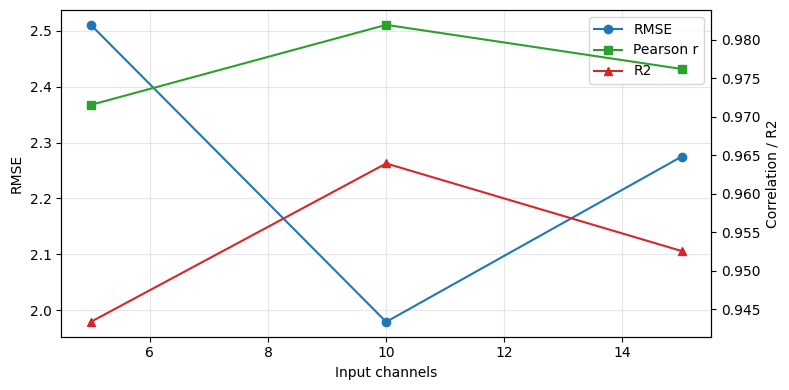

Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Pure_AI_models\deep_cnn\deep_cnn_metrics.csv
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Pure_AI_models\deep_cnn\deep_cnn_summary.json
Saved: E:\Github\EEGFeatureExtraction\Main_codes\Baseline_analysis\Pure_AI_models\deep_cnn\deep_cnn_metrics_plot.png


In [4]:
output_csv=NOTEBOOK_DIR / 'deep_cnn_metrics.csv'
output_json=NOTEBOOK_DIR / 'deep_cnn_summary.json'
plot_path=NOTEBOOK_DIR / 'deep_cnn_metrics_plot.png'
df.to_csv(output_csv, index=False)
summary=df.groupby('n_input_channels', as_index=False)[['rmse','mae','pearson_r','r2']].mean()
output_json.write_text(json.dumps({'rows': int(len(df)), 'splits': int(len(loso_splits)), 'method': 'deep_cnn', 'device': DEVICE, 'mean_metrics': summary.to_dict(orient='records')}, indent=2), encoding='utf-8')
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(summary['n_input_channels'], summary['rmse'], marker='o', label='RMSE')
ax1.set_xlabel('Input channels')
ax1.set_ylabel('RMSE')
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(summary['n_input_channels'], summary['pearson_r'], marker='s', color='tab:green', label='Pearson r')
ax2.plot(summary['n_input_channels'], summary['r2'], marker='^', color='tab:red', label='R2')
ax2.set_ylabel('Correlation / R2')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
fig.tight_layout()
fig.savefig(plot_path, dpi=150)
plt.show()
print('Saved:', output_csv)
print('Saved:', output_json)
print('Saved:', plot_path)